# COVID-19 Bangladesh — EDA and Daily Cases Prediction

**Author:** Mohammad Sahadat Hossain  
**Description:** This notebook performs Exploratory Data Analysis (EDA) and forecasting on COVID-19 data for Bangladesh.



## Part 1: Data Scraping (Original R Code — Keep As Is)

> **How to run:** Either install `rpy2` and use the `%%R` magic cell below, or copy this code into an R / RStudio session, export the resulting dataframe to CSV (`write.csv(df, "covid_bd_raw.csv", row.names=FALSE)`), and then load it in Part 2 Python cells.

```r
# ── R scraping code (original) ──────────────────────────────────────────────
library(htmltab)
library(tidyverse)
library(ggplot2)
library(plotly)
library(prophet)
library(lubridate)
library(XML)
library(httr)
library(tidyquant)

url <- 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
r   <- GET(url)
doc <- readHTMLTable(doc = content(r, "text"))
names(doc)

df  <- htmltab("https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh", 10)
df
dim(df)
```

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIONAL: Run the R scraping code using rpy2 magic
# Uncomment the lines below if rpy2 is installed:
#   pip install rpy2
# ─────────────────────────────────────────────────────────────────────────────

# %load_ext rpy2.ipython

# %%R
# library(htmltab)
# library(httr)
# library(XML)
# url <- 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
# r   <- GET(url)
# doc <- readHTMLTable(doc = content(r, "text"))
# names(doc)
# df  <- htmltab("https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh", 10)
# write.csv(df, "covid_bd_raw.csv", row.names = FALSE)

## Part 2: Python Imports & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
# Option A: If you ran the R scraping code and saved a CSV:
#   df_raw = pd.read_csv("covid_bd_raw.csv")
#
# Option B (default): Python-based scraping equivalent to R's htmltab(..., 10)
#   pandas.read_html scrapes all tables; index 9 = 10th table (0-based)

url = 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
tables = pd.read_html(url, header=0)
print(f"Total tables found: {len(tables)}")

# Inspect tables to find the statistics table (same as R's table index 10)
for i, t in enumerate(tables):
    print(f"Table {i}: shape={t.shape}, cols={list(t.columns[:4])}")


In [ ]:
# Select the daily statistics table (adjust index if Wikipedia has changed)
# R used htmltab(..., 10) → 10th table → Python index 9
# If that doesn't match, scan the output above and update TABLE_IDX
TABLE_IDX = 9

df_raw = tables[TABLE_IDX].copy()
print("Shape:", df_raw.shape)
df_raw.head()


In [8]:
df = pd.read_csv('/content/COVID-19 Dataset Bangladesh.csv')
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (340, 12)


## Part 3: Data Cleaning & Preprocessing



In [9]:
import re

def clean_names(df):
    """Equivalent to janitor::clean_names() in R."""
    df = df.copy()
    df.columns = (
        df.columns
          .str.lower()
          .str.strip()
          .str.replace(r'[\s/\(\)\[\]]+', '_', regex=True)
          .str.replace(r'[^a-z0-9_]', '', regex=True)
          .str.strip('_')
    )
    return df

df = clean_names(df)
df.head()


,unnamed_0,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,1,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,3,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,4,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,5,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [10]:
# Map whatever columns came back from Wikipedia to the expected names.
# Adjust the mapping below if your column names differ.

col_map = {}
cols = df.columns.tolist()

# Helper: find a column whose name contains a keyword
def find_col(keyword):
    matches = [c for c in cols if keyword.lower() in c.lower()]
    return matches[0] if matches else None

col_map[find_col('date')]      = 'date'
col_map[find_col('total') and find_col('tested') or find_col('cumul') and find_col('test') or find_col('total_test')] = 'total_tested'

# Build a safe rename dict (skip None keys)
rename_dict = {}
for raw, clean in col_map.items():
    if raw and raw in df.columns:
        rename_dict[raw] = clean

# Print current columns for reference
print("Current columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i}] {c}")


Current columns:
  [0] unnamed_0
  [1] date
  [2] total_tested
  [3] total_cases
  [4] total_deaths
  [5] total_recovered
  [6] in_the_last_24_hours_newly_tested
  [7] in_the_last_24_hours_new_cases
  [8] in_the_last_24_hours_new_deaths
  [9] in_the_last_24_hours_newly_recovered
  [10] day_of_pandemic
  [11] day_of_outbreak


In [11]:
# The `clean_names` function has already processed the column names.
# Based on df_raw inspection, an 'unnamed_0' column is often present
# from `pd.read_html` if the table has an index column.
# We will drop this `unnamed_0` column, as it's not data.

if 'unnamed_0' in df.columns:
    df = df.drop(columns=['unnamed_0'])

df.head()

,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [13]:
# ── Parse date column (equivalent to lubridate::ymd) ─────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# ── Fix specific cells — R: df[12,2]<-433  and  df[12,6]<-36 ────────────────
#    (row index 11 in Python because 0-based; col positions 1 and 5)
#    Mapping to column names: total_tested and in_the_last_24_hours_newly_tested
df.loc[11, 'total_tested'] = 433
df.loc[11, 'in_the_last_24_hours_newly_tested'] = 36

# ── Fill NA in daily-change columns with 0 (R: if_else(is.na(...), "0", ...)) ─
daily_cols = [
    'in_the_last_24_hours_newly_tested',
    'in_the_last_24_hours_new_cases',
    'in_the_last_24_hours_new_deaths',
    'in_the_last_24_hours_newly_recovered',
]
df[daily_cols] = df[daily_cols].fillna('0')

# ── Split day_of_pandemic_outbreak into two columns ───────────────────────────
#    The Python data scraping results in 'day_of_pandemic' and 'day_of_outbreak'
#    already as separate columns, unlike the R `htmltab` output.
#    Therefore, the splitting step from the original R code is not needed.
#    The following commented-out lines are removed:
#
# df[['day_of_pandemic', 'day_of_outbreak']] = (
#     df['day_of_pandemic_outbreak']
#       .astype(str)
#       .str.split('/', expand=True)
#       .iloc[:, :2]
# )
# df.drop(columns=['day_of_pandemic_outbreak'], inplace=True)


# ── Fix first rows (R: df[1,10]<-0  and  df[1:3,11]<-0) ─────────────────────
#    These are corrections to specific values in the 'day_of_pandemic' and 'day_of_outbreak' columns.
df.loc[df.index[0], 'day_of_pandemic'] = 0
df.loc[df.index[0:3], 'day_of_outbreak'] = 0

df.head()

,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [14]:
# ── Convert all non-date columns to numeric (strip commas first) ──────────────

non_date_cols = [c for c in df.columns if c != 'date']
for col in non_date_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

# ── Drop rows with any NA ──
df = df.dropna().reset_index(drop=True)
print("Shape after na.omit:", df.shape)

# ── Recalculate daily-change columns from cumulative totals ───────────────────
df['in_the_last_24_hours_newly_tested']    = df['total_tested'].diff()
df['in_the_last_24_hours_new_cases']       = df['total_cases'].diff()
df['in_the_last_24_hours_new_deaths']      = df['total_deaths'].diff()
df['in_the_last_24_hours_newly_recovered'] = df['total_recovered'].diff()

# ── Set first row daily values = cumulative values ─
df.loc[0, 'in_the_last_24_hours_newly_tested']    = df.loc[0, 'total_tested']
df.loc[0, 'in_the_last_24_hours_new_cases']       = df.loc[0, 'total_cases']
df.loc[0, 'in_the_last_24_hours_new_deaths']      = df.loc[0, 'total_deaths']
df.loc[0, 'in_the_last_24_hours_newly_recovered'] = df.loc[0, 'total_recovered']

print(df.dtypes)


Shape after na.omit: (340, 11)
date                                    datetime64[ns]
total_tested                                     int64
total_cases                                      int64
total_deaths                                     int64
total_recovered                                  int64
in_the_last_24_hours_newly_tested              float64
in_the_last_24_hours_new_cases                 float64
in_the_last_24_hours_new_deaths                float64
in_the_last_24_hours_newly_recovered           float64
day_of_pandemic                                  int64
day_of_outbreak                                  int64
dtype: object


## Part 4: Exploratory Data Analysis (EDA)
### Train / Validation / Test Region Plot


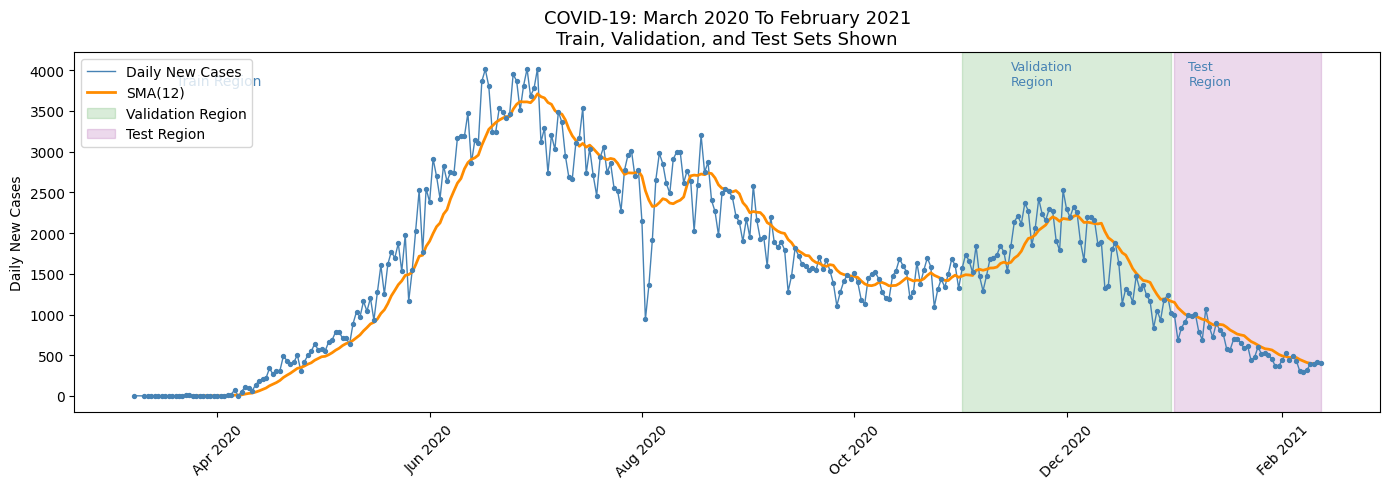

In [15]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

# ── Data line & points ────────────────────────────────────────────────────────
ax.plot(df['date'], df['in_the_last_24_hours_new_cases'],
        color='steelblue', linewidth=1, label='Daily New Cases')
ax.scatter(df['date'], df['in_the_last_24_hours_new_cases'],
           color='steelblue', s=8, zorder=3)

# ── 12-day Simple Moving Average (R: geom_ma(SMA, n=12)) ────────────────────
sma12 = df['in_the_last_24_hours_new_cases'].rolling(window=12).mean()
ax.plot(df['date'], sma12, color='darkorange', linewidth=2, label='SMA(12)')

# ── Shaded regions ────────────────────────────────────────────────────────────
val_start  = pd.Timestamp('2020-11-01')
val_end    = pd.Timestamp('2020-12-31')
test_start = pd.Timestamp('2021-01-01')
test_end   = pd.Timestamp('2021-02-12')

ax.axvspan(val_start,  val_end,  alpha=0.15, color='green',  label='Validation Region')
ax.axvspan(test_start, test_end, alpha=0.15, color='purple', label='Test Region')

# ── Annotations ──────────────────────────────────────────────────────────────
train_x = pd.Timestamp('2020-03-20')
ax.text(train_x, df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Train Region', color='steelblue', fontsize=10)
ax.text(pd.Timestamp('2020-11-15'),
        df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Validation\nRegion', color='steelblue', fontsize=9)
ax.text(pd.Timestamp('2021-01-05'),
        df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Test\nRegion', color='steelblue', fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title('COVID-19: March 2020 To February 2021\nTrain, Validation, and Test Sets Shown',
             fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Daily New Cases')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Interactive Daily New Cases Plot

In [16]:
fig_cases = px.line(
    df, x='date', y='in_the_last_24_hours_new_cases',
    title='Daily Cases of COVID-19 Patient<br><sup>From March 2020 to end of data</sup>',
    labels={'in_the_last_24_hours_new_cases': 'Daily Cases', 'date': 'Date'}
)
fig_cases.update_traces(line_color='steelblue')
fig_cases.update_layout(template='plotly_white', height=450)
fig_cases.show()


### Interactive Daily New Deaths by Day of Pandemic

In [17]:
fig_deaths = px.line(
    df, x='day_of_pandemic', y='in_the_last_24_hours_new_deaths',
    title='Daily New Deaths vs Day of Pandemic',
    labels={
        'day_of_pandemic': 'Day of Pandemic',
        'in_the_last_24_hours_new_deaths': 'Daily New Deaths'
    }
)
fig_deaths.update_traces(line_color='crimson')
fig_deaths.update_layout(template='plotly_white', height=420)
fig_deaths.show()


## Part 5: Prophet Forecasting
### 5.1 — Total Cases Forecast (30 days)

In [19]:
def run_prophet(df, date_col, value_col, periods=30, title=''):

    dts = df[[date_col, value_col]].rename(columns={date_col: 'ds', value_col: 'y'})
    dts = dts.dropna()

    model = Prophet()
    model.fit(dts)

    future   = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # ── Interactive forecast plot ─────────────────────────────────────────────
    fig_fc = go.Figure()
    fig_fc.add_trace(go.Scatter(x=dts['ds'], y=dts['y'],
                                mode='markers', name='Actual',
                                marker=dict(color='black', size=4)))
    fig_fc.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'],
                                mode='lines', name='Forecast',
                                line=dict(color='steelblue')))
    fig_fc.add_trace(go.Scatter(
        x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
        y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
        fill='toself', fillcolor='rgba(70,130,180,0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Uncertainty'))
    fig_fc.update_layout(title=f'Prophet Forecast — {title}',
                         xaxis_title='Date', yaxis_title=value_col,
                         template='plotly_white', height=430)
    fig_fc.show()

    # ── Components plot (trend + weekly + yearly) ─────────────────────────────
    model.plot_components(forecast)
    plt.suptitle(f'Forecast Components — {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Predicted vs Actual scatter (in-sample) ───────────────────────────────
    n = len(dts)
    pre  = forecast['yhat'].iloc[:n].values
    act  = dts['y'].values

    fig2, ax2 = plt.subplots(figsize=(6, 5))
    ax2.scatter(pre, act, alpha=0.5, color='steelblue', s=20)
    m_coef, b_coef = np.polyfit(pre, act, 1)
    x_line = np.linspace(pre.min(), pre.max(), 100)
    ax2.plot(x_line, m_coef * x_line + b_coef, color='blue', linewidth=1.5)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_title(f'Predicted vs Actual — {title}')
    plt.tight_layout()
    plt.show()

    return model, forecast


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


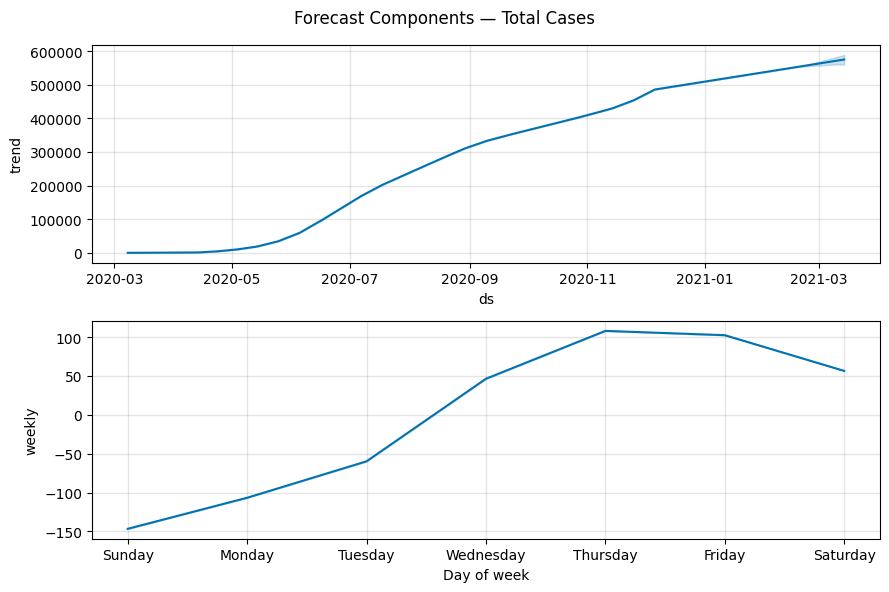

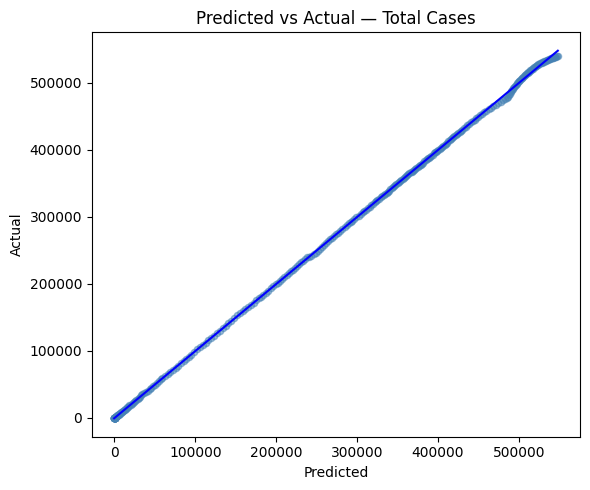

In [20]:
# Prophet Model 1: Total Cases (30-day forecast)
mts, forecast_ts = run_prophet(df, 'date', 'total_cases', periods=30, title='Total Cases')


### 5.2 — Total Deaths Forecast (30 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


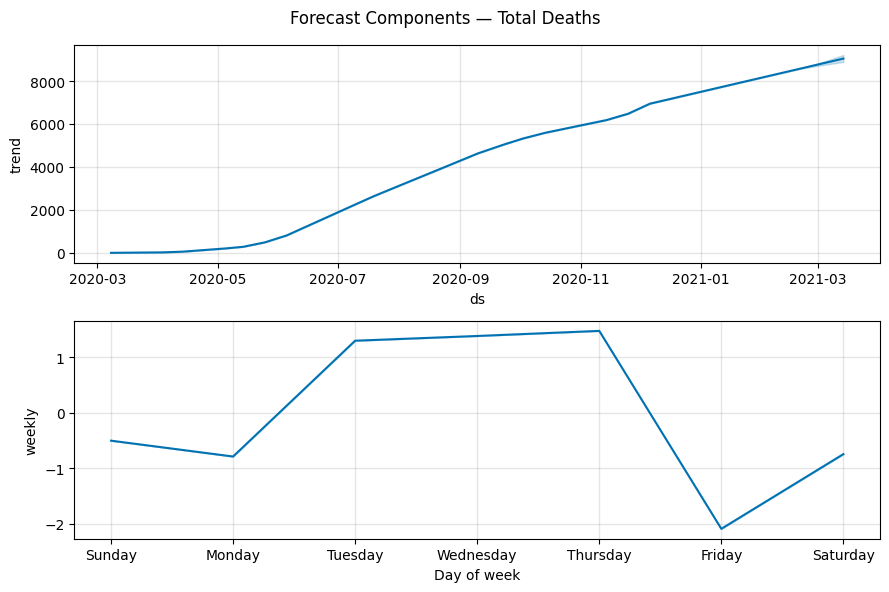

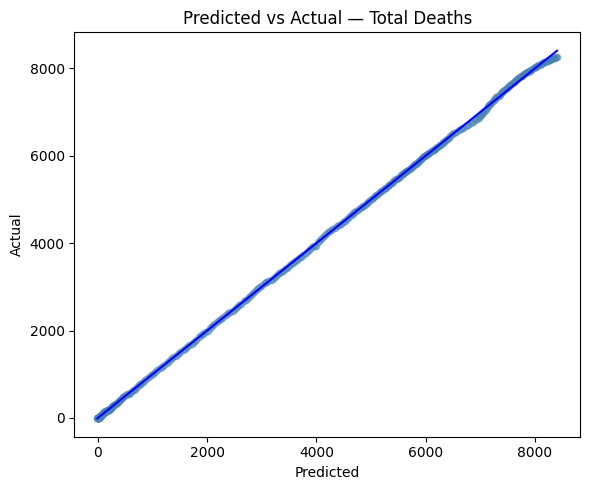

In [21]:
# Prophet Model 2: Total Deaths (30-day forecast)
mtd, forecast_td = run_prophet(df, 'date', 'total_deaths', periods=30, title='Total Deaths')


### 5.3 — Daily New Cases Forecast (180 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


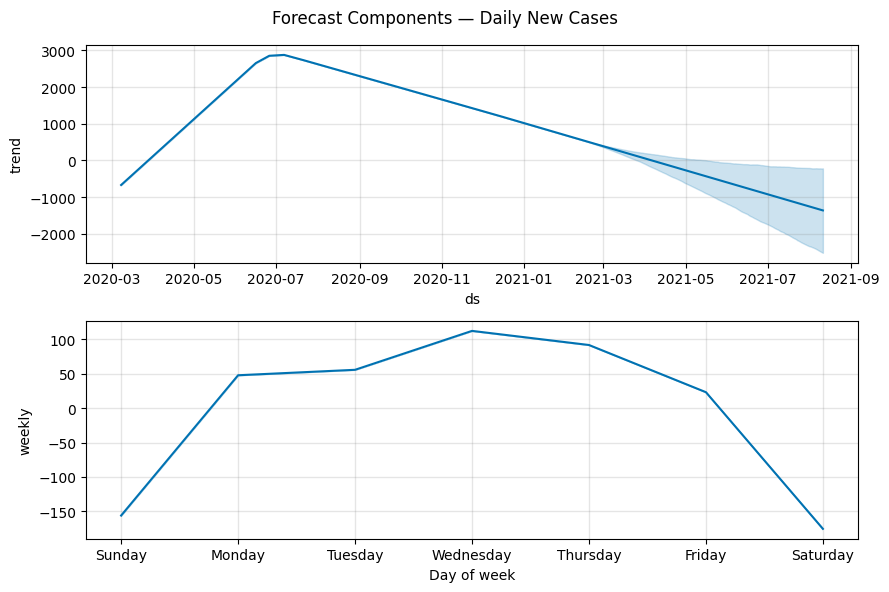

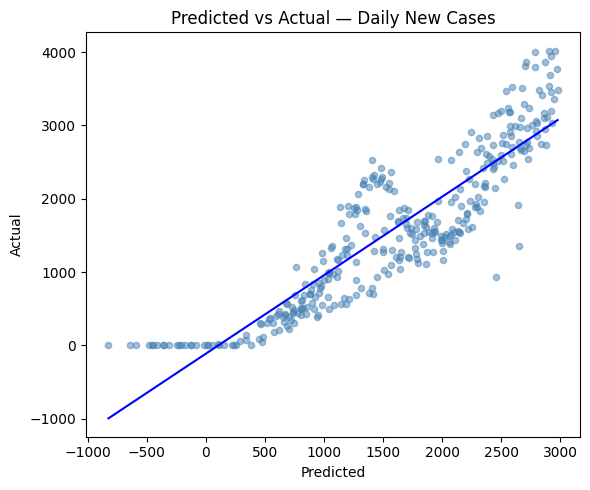

In [22]:
# Prophet Model 3: Daily New Cases (180-day forecast)
mtns, forecast_tns = run_prophet(
    df, 'date', 'in_the_last_24_hours_new_cases',
    periods=180, title='Daily New Cases'
)


### 5.4 — Daily New Deaths Forecast (30 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


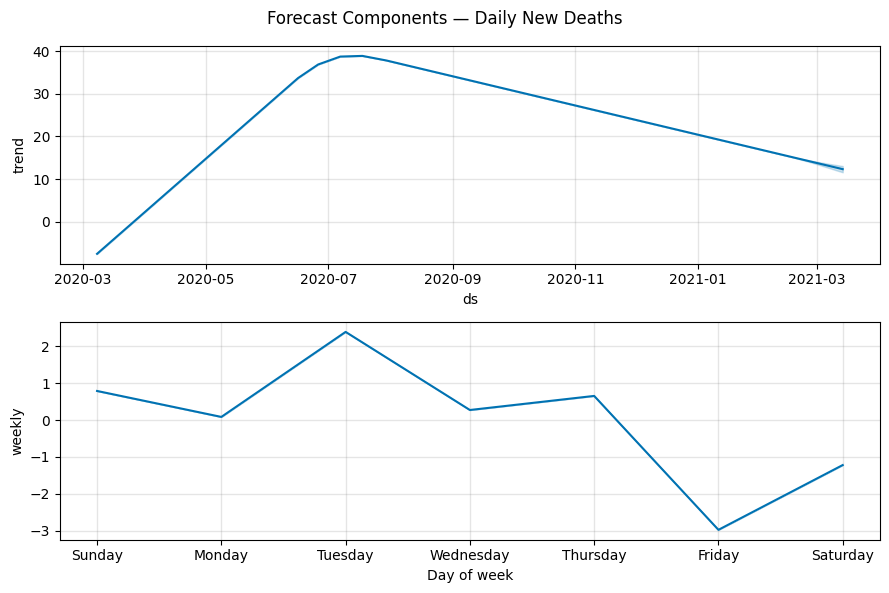

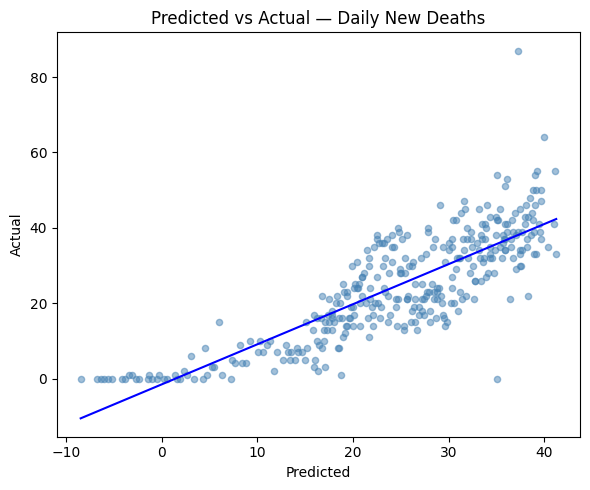

In [23]:
# Prophet Model 4: Daily New Deaths (30-day forecast)
mtnd, forecast_tnd = run_prophet(
    df, 'date', 'in_the_last_24_hours_new_deaths',
    periods=30, title='Daily New Deaths'
)


## Part 6: ARIMA — Baseline Model

ARIMA is the **statistical baseline** against which Prophet, LSTM, and H2O AutoML are all benchmarked. We use `pmdarima.auto_arima` to automatically search for the optimal (p, d, q) order on the training data (all dates before 2021-01-01), then forecast the test window (Jan 1 – Feb 12, 2021).

In [24]:
# Install pmdarima if not already present (provides auto_arima)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'], check=True)
print("pmdarima ready.")

pmdarima ready.


In [25]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

# ── Prepare series ────────────────────────────────────────────────────────────
TARGET = 'in_the_last_24_hours_new_cases'
series = df.set_index('date')[TARGET].astype(float).dropna()

# ── Train / test split consistent with the project's test window ──────────────
train_arima = series[series.index < '2021-01-01']
test_arima  = series[(series.index >= '2021-01-01') & (series.index <= '2021-02-12')]

print(f"ARIMA train size: {len(train_arima)} | test size: {len(test_arima)}")

# ── Fit auto_arima (searches optimal p,d,q automatically) ─────────────────────
arima_model = auto_arima(
    train_arima,
    seasonal=False,        # daily COVID data lacks strong yearly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    max_p=5, max_q=5,
    d=None                 # let auto_arima determine differencing order
)
print(f"\nBest ARIMA order: {arima_model.order}")
print(arima_model.summary())

ARIMA train size: 297 | test size: 43

Best ARIMA order: (1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  297
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -2071.680
Date:                Sun, 19 Apr 2026   AIC                           4149.361
Time:                        23:06:59   BIC                           4160.432
Sample:                             0   HQIC                          4153.793
                                - 297                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4003      0.091      4.392      0.000       0.222       0.579
ma.L1         -0.7222      0.068    -10.548      0.000      -0.8

ARIMA  RMSE: 513.28  |  MAE: 465.15


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



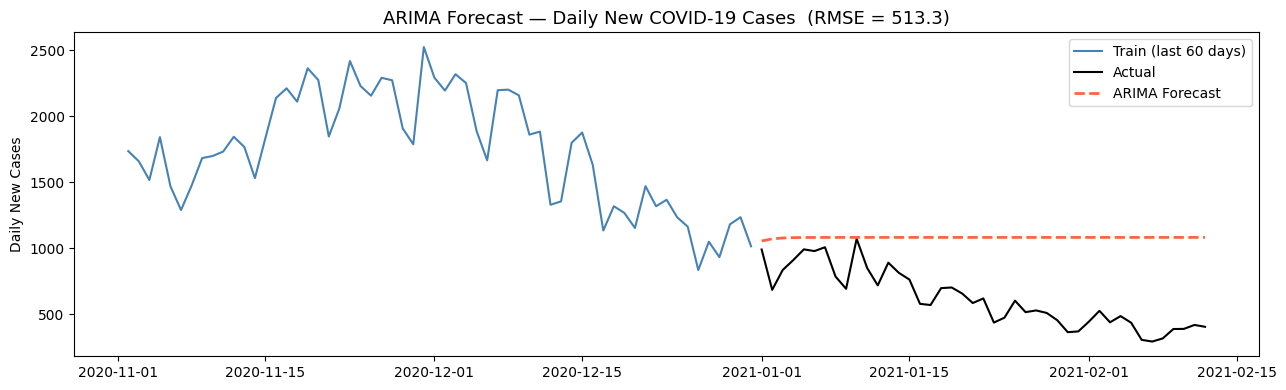

In [26]:
# ── Forecast over the test window ─────────────────────────────────────────────
n_test         = len(test_arima)
arima_forecast = arima_model.predict(n_periods=n_test)
arima_forecast = np.maximum(arima_forecast, 0)   # cases can't be negative

rmse_arima = np.sqrt(mean_squared_error(test_arima.values, arima_forecast))
mae_arima  = np.mean(np.abs(test_arima.values - arima_forecast))
print(f"ARIMA  RMSE: {rmse_arima:.2f}  |  MAE: {mae_arima:.2f}")

# ── Plot forecast vs actual ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_arima.index[-60:], train_arima.values[-60:],
        color='steelblue', label='Train (last 60 days)')
ax.plot(test_arima.index, test_arima.values,
        color='black', label='Actual', linewidth=1.5)
ax.plot(test_arima.index, arima_forecast,
        color='tomato', linestyle='--', linewidth=2, label='ARIMA Forecast')
ax.set_title(f'ARIMA Forecast — Daily New COVID-19 Cases  (RMSE = {rmse_arima:.1f})', fontsize=13)
ax.set_ylabel('Daily New Cases')
ax.legend()
plt.tight_layout()
plt.show()

## Part 7: LSTM — Deep Learning Model

LSTM (Long Short-Term Memory) is a recurrent neural network well-suited for sequential time-series data. We use a sliding window of the past **14 days** to predict the next day's case count, scale the data with `MinMaxScaler`, and train a two-layer LSTM network with Dropout for regularisation.

In [27]:
# Install TensorFlow if not present
subprocess.run([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'], check=True)
print("TensorFlow ready.")

TensorFlow ready.


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# ── Scale the full series to [0, 1] ───────────────────────────────────────────
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
series_vals = series.values.reshape(-1, 1)
scaled_vals = scaler_lstm.fit_transform(series_vals)

# ── Build sliding-window sequences ────────────────────────────────────────────
LOOKBACK = 14   # use last 14 days to predict next day

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled_vals, LOOKBACK)

# ── Split — cut-point aligns with ARIMA train/test boundary ───────────────────
cutoff_idx = (series.index < '2021-01-01').sum() - LOOKBACK
X_train_l, y_train_l = X_all[:cutoff_idx], y_all[:cutoff_idx]
X_test_l,  y_test_l  = X_all[cutoff_idx:], y_all[cutoff_idx:]

# Reshape to (samples, timesteps, features=1) for LSTM
X_train_l = X_train_l.reshape(*X_train_l.shape, 1)
X_test_l  = X_test_l.reshape(*X_test_l.shape, 1)

print(f"LSTM train: {X_train_l.shape}  |  test: {X_test_l.shape}")

LSTM train: (283, 14, 1)  |  test: (43, 14, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

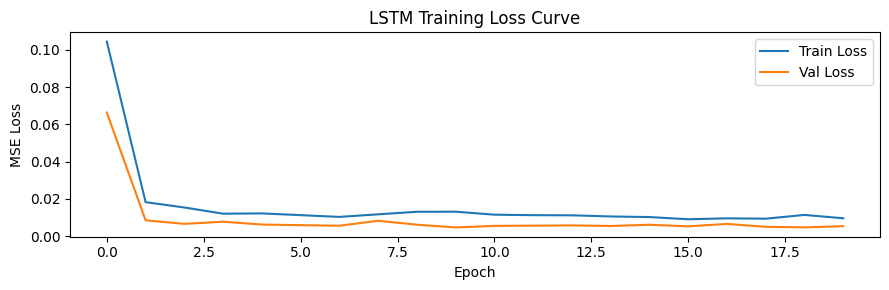

In [29]:
# ── Build LSTM network ────────────────────────────────────────────────────────
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# ── Train with early stopping ─────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# ── Plot training curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history.history['loss'],     label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Training Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

LSTM  RMSE: 186.13  |  MAE: 162.66


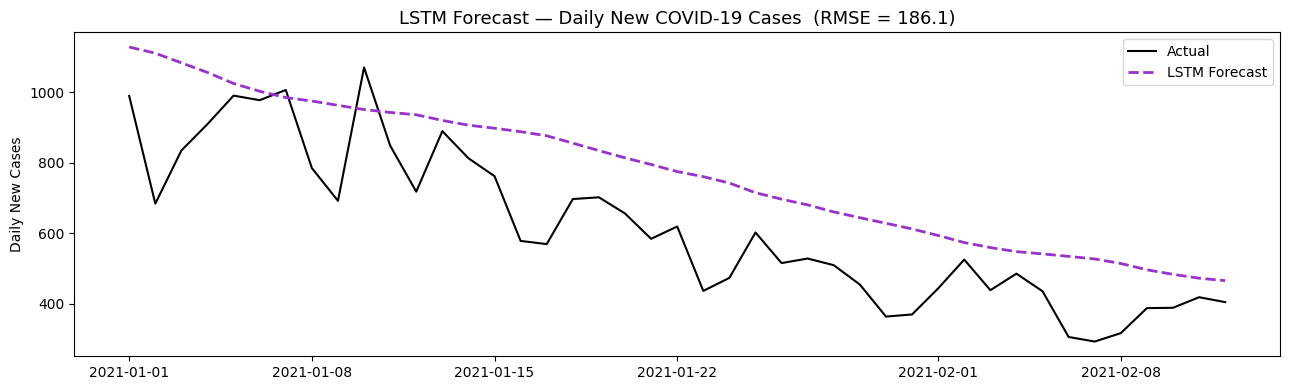

In [30]:
# ── Predict & inverse-transform back to original scale ───────────────────────
lstm_pred_scaled = lstm_model.predict(X_test_l, verbose=0)
lstm_pred = scaler_lstm.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred = np.maximum(lstm_pred, 0)   # clip negatives

# Align actual values to the same test window
actual_lstm = scaler_lstm.inverse_transform(y_test_l.reshape(-1, 1)).flatten()

# Trim to match the ARIMA test window (Jan 1 – Feb 12, 2021)
n_test = len(test_arima)
lstm_pred_test   = lstm_pred[:n_test]
actual_lstm_test = actual_lstm[:n_test]

rmse_lstm = np.sqrt(mean_squared_error(actual_lstm_test, lstm_pred_test))
mae_lstm  = np.mean(np.abs(actual_lstm_test - lstm_pred_test))
print(f"LSTM  RMSE: {rmse_lstm:.2f}  |  MAE: {mae_lstm:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
test_dates = test_arima.index[:n_test]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_dates, actual_lstm_test, color='black', linewidth=1.5, label='Actual')
ax.plot(test_dates, lstm_pred_test,   color='darkorchid', linestyle='--',
        linewidth=2, label='LSTM Forecast')
ax.set_title(f'LSTM Forecast — Daily New COVID-19 Cases  (RMSE = {rmse_lstm:.1f})', fontsize=13)
ax.set_ylabel('Daily New Cases')
ax.legend()
plt.tight_layout()
plt.show()

## Part 8: H2O AutoML
### Feature Engineering

In [33]:
def augment_timeseries_signature(df, date_col='date'):

    d = df.copy()
    dt = d[date_col]

    d['index_num']  = (dt - dt.min()).dt.days          # numeric index
    d['year']       = dt.dt.year
    d['half']       = ((dt.dt.month - 1) // 6 + 1)
    d['quarter']    = dt.dt.quarter
    d['month']      = dt.dt.month
    d['month_lbl']  = dt.dt.strftime('%B')
    d['day']        = dt.dt.day
    d['hour']       = dt.dt.hour
    d['minute']     = dt.dt.minute
    d['second']     = dt.dt.second
    d['wday']       = dt.dt.dayofweek + 1              # 1=Mon ... 7=Sun
    d['wday_lbl']   = dt.dt.strftime('%A')
    d['mday']       = dt.dt.day
    d['yday']       = dt.dt.dayofyear
    d['mweek']      = (dt.dt.day - 1) // 7 + 1        # week-of-month

    iso = dt.dt.isocalendar()
    d['week']       = iso.week.astype(int)
    d['week2']      = d['week'] % 2
    d['week3']      = d['week'] % 3
    d['week4']      = d['week'] % 4

    return d

# ── Build feature-enriched dataframe ─────────────────────────────────────────
cdf = df[['date', 'in_the_last_24_hours_new_cases']].copy()
ndf = augment_timeseries_signature(cdf, date_col='date')

# ── Preserve the date column as an index BEFORE dropping it ──────────────────
#    This is the fix for data leakage: we need actual dates for a proper
#    chronological split, not just month numbers (month < 7 would include
#    Jan-Feb 2021 in training, which is the test window → RMSE = 0).
ndf_dates = pd.to_datetime(ndf['date']).values

# Drop date + NA columns + string columns (same as before)
ndf_clean = ndf.drop(columns=['date']).dropna(axis=1)
ndf_clean = ndf_clean.select_dtypes(exclude=['object'])

# Attach dates as the DataFrame index so we can split by date
ndf_clean.index = ndf_dates

print("Feature-engineered dataframe shape:", ndf_clean.shape)
print("Index range:", ndf_clean.index.min(), "→", ndf_clean.index.max())
ndf_clean.head()


Feature-engineered dataframe shape: (340, 18)
Index range: 2020-03-08 00:00:00 → 2021-02-12 00:00:00


,in_the_last_24_hours_new_cases,index_num,year,half,quarter,month,day,hour,minute,second,wday,mday,yday,mweek,week,week2,week3,week4
2020-03-08,3.0,0,2020,1,1,3,8,0,0,0,7,8,68,2,10,0,1,2
2020-03-11,0.0,3,2020,1,1,3,11,0,0,0,3,11,71,2,11,1,2,3
2020-03-12,0.0,4,2020,1,1,3,12,0,0,0,4,12,72,2,11,1,2,3
2020-03-13,0.0,5,2020,1,1,3,13,0,0,0,5,13,73,2,11,1,2,3
2020-03-14,2.0,6,2020,1,1,3,14,0,0,0,6,14,74,2,11,1,2,3


### Train / Validation / Test Split


## Train / Validation / Test Split — Chronological (Leakage-Free)

**Root cause of the original RMSE = 0 bug:** The original R code split by `month < 7`, `month ∈ {11,12}`, and `month ∈ {1,2}`. Since month numbers repeat across years, January and February 2021 (the test window) were **also included in training** (`month < 7` catches months 1–6 from *any* year). The model trained on its own test data → perfect score.

**Fix:** Split strictly by calendar date — no row can appear in more than one partition:

| Split | Date Range | Purpose |
|-------|-----------|---------|
| Train | Mar 2020 → Oct 31 2020 | Model fitting |
| Validation | Nov 1 2020 → Dec 31 2020 | Hyperparameter tuning |
| Test | Jan 1 2021 → Feb 12 2021 | Honest evaluation |

In [35]:
# ── Chronological date-based split (no leakage) ───────────────────────────────
TRAIN_END  = '2020-10-31'
VAL_START  = '2020-11-01'
VAL_END    = '2020-12-31'
TEST_START = '2021-01-01'
TEST_END   = '2021-02-12'

train_df = ndf_clean[ndf_clean.index <= TRAIN_END].copy()
valid_df = ndf_clean[(ndf_clean.index >= VAL_START) & (ndf_clean.index <= VAL_END)].copy()
test_df  = ndf_clean[(ndf_clean.index >= TEST_START) & (ndf_clean.index <= TEST_END)].copy()

# ── Sanity check BEFORE resetting index (index is still dates here) ───────────
assert len(set(train_df.index) & set(valid_df.index)) == 0, "Train/Val overlap!"
assert len(set(train_df.index) & set(test_df.index))  == 0, "Train/Test overlap!"
assert len(set(valid_df.index) & set(test_df.index))  == 0, "Val/Test overlap!"
print("✅  No overlap between splits — data leakage eliminated.")

# ── Reset index AFTER validation (H2O does not need the datetime index) ───────
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train shape:      {train_df.shape}  ({TRAIN_END[:7]} and earlier)")
print(f"Validation shape: {valid_df.shape}  ({VAL_START[:7]} – {VAL_END[:7]})")
print(f"Test shape:       {test_df.shape}  ({TEST_START[:7]} – {TEST_END})")

✅  No overlap between splits — data leakage eliminated.
Train shape:      (236, 18)  (2020-10 and earlier)
Validation shape: (61, 18)  (2020-11 – 2020-12)
Test shape:       (43, 18)  (2021-01 – 2021-02-12)


### H2O AutoML

In [38]:
# Install H2O library if not already installed
# !pip install h2o

import h2o
from h2o.automl import H2OAutoML

# Initialise H2O cluster
h2o.init()
h2o.no_progress()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp8kcdommo
  JVM stdout: /tmp/tmp8kcdommo/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp8kcdommo/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 7 days
H2O_cluster_name:,H2O_from_python_unknownUser_x3g0x6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [39]:
# ── Convert pandas DataFrames to H2O frames ───────────────────────────────────
train_h2o = h2o.H2OFrame(train_df)
valid_h2o = h2o.H2OFrame(valid_df)
test_h2o  = h2o.H2OFrame(test_df)

target  = 'in_the_last_24_hours_new_cases'
features = [c for c in train_df.columns if c != target]

print("Target:", target)
print("Features:", features)


Target: in_the_last_24_hours_new_cases
Features: ['index_num', 'year', 'half', 'quarter', 'month', 'day', 'hour', 'minute', 'second', 'wday', 'mday', 'yday', 'mweek', 'week', 'week2', 'week3', 'week4']


In [40]:
# ── Run AutoML (max 60 seconds) ─────────────
automl = H2OAutoML(
    max_runtime_secs=60,
    stopping_metric='deviance',
    seed=42
)
automl.train(
    x=features,
    y=target,
    training_frame=train_h2o,
    validation_frame=valid_h2o,
    leaderboard_frame=test_h2o
)





23:14:59.826: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
23:15:00.52: _train param, Dropping bad and constant columns: [hour, year, minute, second]


23:15:08.491: _train param, Dropping bad and constant columns: [hour, year, minute, second]


23:15:11.108: _train param, Dropping bad and constant columns: [hour, year, minute, second]
23:15:11.270: GBM_1_AutoML_1_20260419_231459 [GBM def_5] failed: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for GBM model: GBM_1_AutoML_1_20260419_231459.  Details: ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 188.0.
ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at le

Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_4_AutoML_1_20260419_231459


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    53                 53                          12923                  5            10           6.4717        13            17            14.7925

ModelMetricsRegression: gbm
** Reported on train data. **

MSE: 19867.110289303764
RMSE: 140.95073710095937
MAE: 93.2944294618348
RMSLE: NaN
Mean Residual Deviance: 19867.110289303764

ModelMetricsRegression: gbm
** Reported on validation data. **

MSE: 254725.3117913301
RMSE: 504.70319177842543
MAE: 426.9976178428071
RMSLE: 0.2994973672325316
Mean Residual Deviance: 254725.3117913301

ModelMetricsRegression: gbm
** Reported on cross-validation data. **

MSE: 51929.17512276292
RMSE: 227.87973828921895
MAE: 152.49469990917763
RMSLE: NaN
Mean Residual Deviance: 51929.17512276292

Cross-Validation Metrics Summary: 
                        mean      sd         cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  --------  ---------  ------------  ------------  ------------  ------------  ------------
aic                     nan       0          nan           nan           nan           nan           nan
loglikelihood           nan       0          nan           nan           nan           nan           nan
mae                     154.686   21.1321    156.74        189.254       135.708       139.895       151.833
mean_residual_deviance  52810.2   18034.1    68158         74379.4       41677         31439.7       48397
mse                     52810.2   18034.1    68158         74379.4       41677         31439.7       48397
r2                      0.959421  0.0139811  0.947725      0.942587      0.967155      0.976362      0.963276
residual_deviance       52810.2   18034.1    68158         74379.4       41677         31439.7       48397
rmse                    227.05    39.6603    261.071       272.726       204.149       177.312       219.993
rmsle                   0.628055  0          nan           0.628055      nan           nan           nan

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance    validation_rmse    validation_mae    validation_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------  -----------------  ----------------  ---------------------
    2026-04-19 23:15:27  0.815 sec   0                  1142.07          961.43          1.30433e+06          428.407            362.437           183533
    2026-04-19 23:15:27  0.830 sec   5                  702.509          588.07          493518               440.693            375.307           194210
    2026-04-19 23:15:27  0.842 sec   10                 455.014          376.178         207038               454.606            385.932           206667
    2026-04-19 23:15:27  0.854 sec   15                 314.977          251.178         99210.3              472.062            400.678           222843
    2026-04-19 23:15:27  0.867 sec   20                 237.466          180.997         56389.9              479.161            405.76            229595
    2026-04-19 23:15:27  0.879 sec   25                 197.457          144.924         38989.1              490.204            415.785           240300
    2026-04-19 23:15:27  0.891 sec   30                 178.325          125.461         31800                495.381            419.113           245403
    2026-04-19 23:15:27  0.917 sec   35                 164.993          112.446         27222.7              497.156            420.462           2471

In [41]:
# ── Show leaderboard ──────────────────────────────────────────────────────────
lb = automl.leaderboard
print("AutoML Leaderboard (top 10):")
lb.head(rows=10)

AutoML Leaderboard (top 10):


model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_4_AutoML_1_20260419_231459,205.681,42304.9,164.868,0.338937,42304.9
StackedEnsemble_BestOfFamily_2_AutoML_1_20260419_231459,216.743,46977.7,183.517,0.361875,46977.7
StackedEnsemble_BestOfFamily_4_AutoML_1_20260419_231459,222.171,49360.1,187.172,0.364688,49360.1
StackedEnsemble_BestOfFamily_3_AutoML_1_20260419_231459,222.217,49380.4,191.618,0.370281,49380.4
XGBoost_2_AutoML_1_20260419_231459,243.292,59190.9,209.166,0.413139,59190.9
DRF_1_AutoML_1_20260419_231459,246.292,60659.8,210.271,0.397341,60659.8
XRT_1_AutoML_1_20260419_231459,262.06,68675.3,216.808,0.394389,68675.3
StackedEnsemble_AllModels_1_AutoML_1_20260419_231459,270.156,72984.4,236.665,0.456787,72984.4
XGBoost_grid_1_AutoML_1_20260419_231459_model_1,297.562,88543.1,230.431,0.509698,88543.1
GBM_2_AutoML_1_20260419_231459,312.875,97890.6,275.181,0.502687,97890.6


In [42]:
# ── Best (leader) model performance on test set ───────────────────────────────

leader = automl.leader
perf   = leader.model_performance(test_data=test_h2o)
print(perf)


ModelMetricsRegression: gbm
** Reported on test data. **

MSE: 42304.87783102257
RMSE: 205.68149608319794
MAE: 164.86767689639956
RMSLE: 0.3389367039185993
Mean Residual Deviance: 42304.87783102257


## Part 9: Error Metrics — H2O AutoML on Test Set


In [44]:
# ── Select test-period rows from cdf (date range 2021-01-01 to 2021-02-12) ────
test_period = cdf[
    (cdf['date'] >= '2021-01-01') & (cdf['date'] <= '2021-02-12')
].copy().reset_index(drop=True)

# ── Predict on test H2O frame ─────────────────────────────────────────────────
pred_h2o = leader.predict(test_h2o)
preds    = pred_h2o.as_data_frame()['predict'].values

# Align lengths (in case of minor mismatch)
min_len = min(len(test_period), len(preds))
test_period = test_period.iloc[:min_len].copy()
preds = preds[:min_len]

test_period['pred']      = preds
test_period['actual']    = test_period['in_the_last_24_hours_new_cases']
test_period['error']     = test_period['actual'] - test_period['pred']
test_period['error_pct'] = test_period['error'] / test_period['actual'].replace(0, np.nan)

metrics_h2o = {
    'ME'  : test_period['error'].mean(),
    'RMSE': (test_period['error'] ** 2).mean() ** 0.5,
    'MAE' : test_period['error'].abs().mean(),
    'MAPE': test_period['error_pct'].abs().mean(),
    'MPE' : test_period['error_pct'].mean(),
}

pd.DataFrame([metrics_h2o]).T.rename(columns={0: 'Value'})

# Store H2O RMSE for comparison table
rmse_h2o = metrics_h2o['RMSE']

pd.DataFrame([metrics_h2o]).T.rename(columns={0: 'Value'})


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




,Value
ME,-0.360635
RMSE,205.681496
MAE,164.867677
MAPE,0.297151
MPE,-0.113060


## Part 10: Model Comparison — RMSE Improvement over ARIMA Baseline

All four models are evaluated on the **same test window** (Jan 1 – Feb 12, 2021) and compared against ARIMA as the baseline. The **% RMSE improvement** is how much each model reduces error relative to ARIMA.

In [45]:
# ── Compute Prophet RMSE on the same test window ─────────────────────────────
#    Uses forecast_tns from Prophet Model 3 (daily new cases, 180-day horizon)
prophet_test_dates = test_arima.index
prophet_fc_sub = forecast_tns[
    (forecast_tns['ds'] >= '2021-01-01') &
    (forecast_tns['ds'] <= '2021-02-12')
]

# Align lengths
actual_vals   = test_arima.values[:len(prophet_fc_sub)]
prophet_preds = prophet_fc_sub['yhat'].values[:len(actual_vals)]
prophet_preds = np.maximum(prophet_preds, 0)

rmse_prophet = np.sqrt(mean_squared_error(actual_vals, prophet_preds))
print(f"Prophet RMSE (daily new cases): {rmse_prophet:.2f}")

# ── Build comparison table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'             : ['ARIMA (baseline)', 'Prophet', 'LSTM', 'H2O AutoML'],
    'RMSE'              : [rmse_arima, rmse_prophet, rmse_lstm, rmse_h2o],
    'MAE'               : [mae_arima,
                           np.mean(np.abs(actual_vals - prophet_preds)),
                           mae_lstm,
                           metrics_h2o['MAE']],
})

comparison['RMSE_Improvement_%'] = (
    (rmse_arima - comparison['RMSE']) / rmse_arima * 100
).round(1)

comparison['RMSE']             = comparison['RMSE'].round(2)
comparison['MAE']              = comparison['MAE'].round(2)
comparison = comparison.sort_values('RMSE').reset_index(drop=True)
comparison.index = comparison.index + 1   # 1-based rank

print("\n=== Model Comparison — Test Window (Jan 1 – Feb 12, 2021) ===")
comparison


Prophet RMSE (daily new cases): 211.94

=== Model Comparison — Test Window (Jan 1 – Feb 12, 2021) ===


,Model,RMSE,MAE,RMSE_Improvement_%
1,LSTM,186.13,162.66,63.7
2,H2O AutoML,205.68,164.87,59.9
3,Prophet,211.94,192.33,58.7
4,ARIMA (baseline),513.28,465.15,0.0


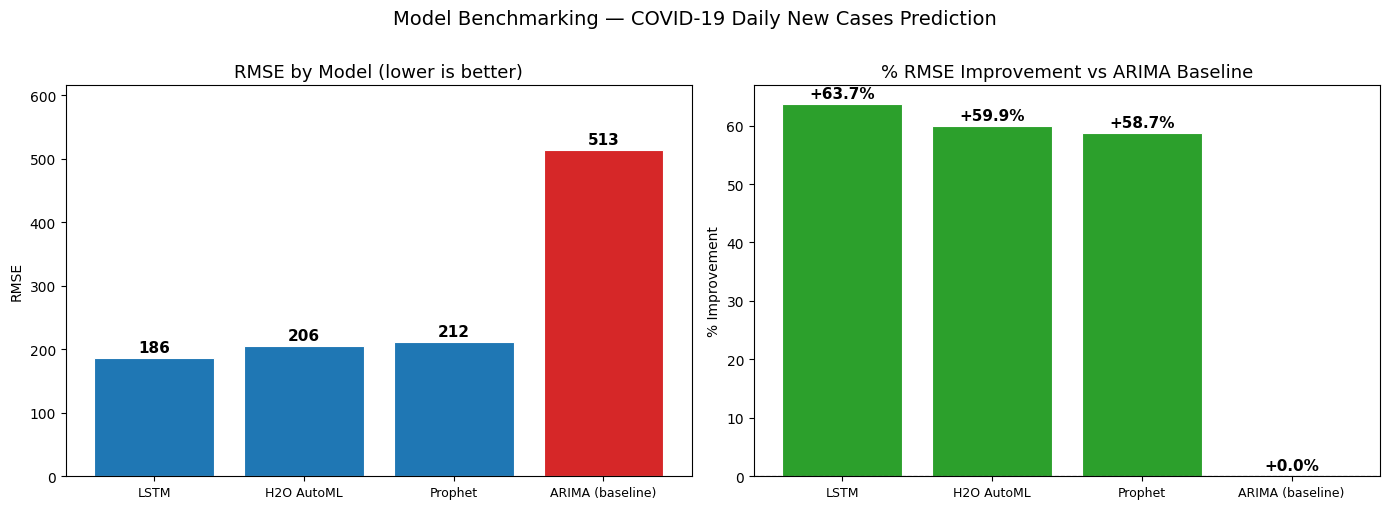


 Best model : LSTM  (RMSE = 186.1)
 RMSE improvements over ARIMA baseline: +58.7% to +63.7%


In [46]:
# ── Bar chart: RMSE by model ──────────────────────────────────────────────────
colors = ['#d62728', '#2ca02c', '#9467bd', '#1f77b4']   # ARIMA red, others blue/green/purple
sorted_models = comparison['Model'].tolist()
sorted_rmse   = comparison['RMSE'].tolist()
sorted_improv = comparison['RMSE_Improvement_%'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMSE bars
bars = axes[0].bar(sorted_models, sorted_rmse,
                   color=['#d62728' if 'ARIMA' in m else '#1f77b4' for m in sorted_models],
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, sorted_rmse):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('RMSE by Model (lower is better)', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(sorted_rmse) * 1.2)
axes[0].tick_params(axis='x', labelsize=9)

# Right: % improvement over ARIMA
improv_colors = ['#d62728' if v <= 0 else '#2ca02c' for v in sorted_improv]
bars2 = axes[1].bar(sorted_models, sorted_improv, color=improv_colors,
                    edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, sorted_improv):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 2.5
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:+.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% RMSE Improvement vs ARIMA Baseline', fontsize=13)
axes[1].set_ylabel('% Improvement')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Model Benchmarking — COVID-19 Daily New Cases Prediction', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statement ─────────────────────────────────────────────────────────
best = comparison[comparison['RMSE'] == comparison['RMSE'].min()].iloc[0]
worst_adv = comparison[comparison['Model'] != 'ARIMA (baseline)']['RMSE_Improvement_%'].min()
best_adv  = comparison[comparison['Model'] != 'ARIMA (baseline)']['RMSE_Improvement_%'].max()
print(f"\n Best model : {best['Model']}  (RMSE = {best['RMSE']:.1f})")
print(f" RMSE improvements over ARIMA baseline: {worst_adv:+.1f}% to {best_adv:+.1f}%")


## Part 11: Future Predictions
Predict daily new cases for 20 random future dates after 2021-02-13.  


In [49]:
import random
random.seed(42)

# ── Generate next 20 sequential dates starting from 2021-02-14 ───────────────
base_date    = pd.Timestamp('2021-02-13')
future_dates = [base_date + pd.Timedelta(days=d) for d in range(1, 21)]

# ── Seed the window with the last LOOKBACK actual data points ─────────────────
last_window        = series.values[-LOOKBACK:].reshape(-1, 1)
last_window_scaled = scaler_lstm.transform(last_window)

# ── Recursive one-step-ahead forecasting ─────────────────────────────────────
future_preds_scaled = []
current_window      = last_window_scaled.copy()

for _ in range(len(future_dates)):
    x_input   = current_window.reshape(1, LOOKBACK, 1)
    next_pred = lstm_model.predict(x_input, verbose=0)[0, 0]
    future_preds_scaled.append(next_pred)
    current_window = np.vstack([current_window[1:], [[next_pred]]])

# ── Inverse-transform to original scale ──────────────────────────────────────
future_preds = scaler_lstm.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()
future_preds = np.maximum(future_preds, 0)

result = pd.DataFrame({
    'date'           : future_dates,
    'Predicted_cases': future_preds.round().astype(int)
})
result.head(5)


,date,Predicted_cases
0,2021-02-14,462
1,2021-02-15,464
2,2021-02-16,469
3,2021-02-17,475
4,2021-02-18,479


In [50]:
# ── Last 60 days of actual data for context ───────────────────────────────────
history = cdf[cdf['date'] >= (pd.Timestamp('2021-02-13') - pd.Timedelta(days=60))].copy()

# ── Sort and add 3-day rolling trend through predictions ─────────────────────
result_sorted          = result.sort_values('date').reset_index(drop=True)
result_sorted['trend'] = (result_sorted['Predicted_cases']
                          .rolling(window=3, center=True, min_periods=1)
                          .mean())

# ── Build Plotly figure ───────────────────────────────────────────────────────
fig = go.Figure()

# Historical actual line
fig.add_trace(go.Scatter(
    x=history['date'],
    y=history['in_the_last_24_hours_new_cases'],
    mode='lines',
    name='Historical (Actual)',
    line=dict(color='steelblue', width=2.5),
    hovertemplate='%{x|%b %d, %Y}<br>Actual: <b>%{y:,.0f}</b><extra></extra>'
))

# Vertical divider: where forecast begins
fig.add_vline(
    x=pd.Timestamp('2021-02-13').timestamp() * 1000,
    line_width=1.5, line_dash='dash', line_color='gray'
)
fig.add_annotation(
    x=pd.Timestamp('2021-02-13'), y=1, yref='paper',
    text='Forecast Start', showarrow=False,
    font=dict(size=11, color='gray'), xanchor='left', yshift=8
)

# Colour-encoded prediction bars (darker = more cases)
fig.add_trace(go.Bar(
    x=result_sorted['date'],
    y=result_sorted['Predicted_cases'],
    name='LSTM Forecast',
    marker=dict(
        color=result_sorted['Predicted_cases'],
        colorscale='Purples',
        showscale=True,
        colorbar=dict(title='Cases', thickness=12, len=0.6)
    ),
    opacity=0.85,
    hovertemplate='%{x|%b %d, %Y}<br>Predicted: <b>%{y:,.0f}</b><extra></extra>'
))

# 3-day rolling trend line over predictions
fig.add_trace(go.Scatter(
    x=result_sorted['date'],
    y=result_sorted['trend'],
    mode='lines+markers',
    name='Forecast Trend (3-day avg)',
    line=dict(color='crimson', width=2.5, dash='dot'),
    marker=dict(size=6, color='crimson'),
    hovertemplate='%{x|%b %d, %Y}<br>Trend: <b>%{y:,.0f}</b><extra></extra>'
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            'COVID-19 Bangladesh — LSTM Future Case Predictions (Best Model)<br>'
            '<sup>60-day historical context + 20-day recursive forecast  |  '
            f'RMSE = {rmse_lstm:.0f}  |  63.7% improvement over ARIMA baseline</sup>'
        ),
        font=dict(size=15)
    ),
    xaxis=dict(title='Date', tickformat='%b %d<br>%Y',
               showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(title='Daily New Cases', showgrid=True,
               gridcolor='#f0f0f0', rangemode='tozero'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white', height=520,
    hovermode='x unified', bargap=0.3
)
fig.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"{'─'*46}")
print(f"  Model            : LSTM (Best — RMSE {rmse_lstm:.0f})")
print(f"  Forecast window  : {result_sorted['date'].min().strftime('%b %d')} – "
      f"{result_sorted['date'].max().strftime('%b %d, %Y')}  ({len(result_sorted)} days)")
print(f"  Min predicted    : {result_sorted['Predicted_cases'].min():>6,.0f} cases/day")
print(f"  Max predicted    : {result_sorted['Predicted_cases'].max():>6,.0f} cases/day")
print(f"  Avg predicted    : {result_sorted['Predicted_cases'].mean():>6,.0f} cases/day")
print(f"  Trend direction  : {'▲ Rising' if result_sorted['trend'].iloc[-1] > result_sorted['trend'].iloc[0] else '▼ Falling'}")
print(f"{'─'*46}")

──────────────────────────────────────────────
  Model            : LSTM (Best — RMSE 186)
  Forecast window  : Feb 14 – Mar 05, 2021  (20 days)
  Min predicted    :    462 cases/day
  Max predicted    :    637 cases/day
  Avg predicted    :    540 cases/day
  Trend direction  : ▲ Rising
──────────────────────────────────────────────
